* Any neural network architecture that processes sequences can be termed as encoder - decoder
* Information bottleneck by encoder on getting all the contextual information in the sequence given to it which has to be processed by the decoder
* Decoder access to all hidden states of encoder - prevent bottleneck - *Attention* 
* Attention alone - not that good since it inherently only works with sequences and computation cannot be parallelised across the input sequence 
* Pre Training or Language Modeling -> Domain Adaptation -> Fine Tuning

# TExt Classification

In [35]:
from huggingface_hub import HfApi
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import torch 
import torch.nn.functional as F
from transformers import AutoTokenizer
from transformers import AutoModel

In [2]:
# This may run or not run not sure - taking ot fo time due to too many datasets ?
# api = HfApi()
# all_datasets = list(api.list_datasets())
# print(f"There are {len(all_datasets)} available in HF currently")

In [3]:
emotions = load_dataset("dair-ai/emotion", cache_dir = "dataset_folder")

In [4]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [6]:
# Dataset object behaves lie an oridnary python array or list 
len(train_ds)

16000

In [7]:
train_ds[23]

{'text': 'i was able to help chai lifeline with your support and encouragement is a great feeling and i am so glad you were able to help me',
 'label': 1}

In [8]:
train_ds.column_names

['text', 'label']

In [9]:
# Based on Apache Arrow - A more optimised columnar format 
print(train_ds.features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [10]:
train_ds[3:8]

{'text': ['i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy',
  'ive been feeling a little burdened lately wasnt sure why that was',
  'ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny',
  'i feel as confused about life as a teenager or as jaded as a year old man'],
 'label': [2, 3, 0, 5, 4]}

In [11]:
emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head(3)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3


In [12]:
def label_string(row):
    return train_ds.features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_string)
df.head(4)

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love


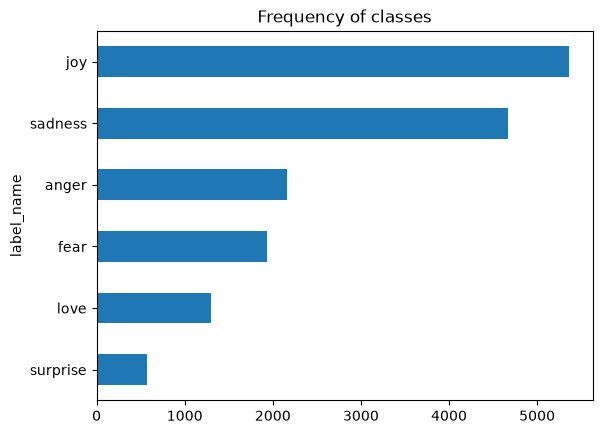

In [13]:
# Data distribution 
df["label_name"].value_counts(ascending=True).plot.barh() 
plt.title("Frequency of classes")
plt.show()

For imbalanced we could have 
* Oversample minority
* Undersample majority
* Get more featuers from minority

Text(0.5, 0.98, '')

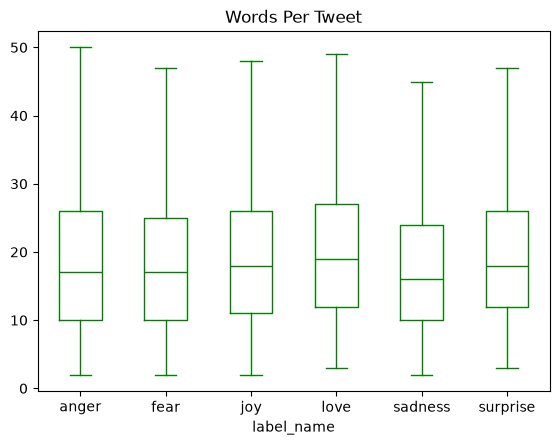

In [14]:
df["Words Per Tweet"] = df["text"].str.split().apply(len)
df.boxplot("Words Per Tweet", by="label_name", grid=False, showfliers=False, color="Green")
plt.suptitle("")

Max length of each tweet is well below the model we are going to work with Context length so no need for any formatting strategy rt now 

In [15]:
emotions.reset_format()

## Character level tokenization

In [16]:
text = train_ds[1]["text"]
tokenized_text = list(text)
print(tokenized_text)

# Each token - give unique numeric id 
token2idx = {character:index for index, character in enumerate(sorted(set(tokenized_text)))}
print(token2idx)
print("Theoretically the vocab size is ", len(token2idx))

['i', ' ', 'c', 'a', 'n', ' ', 'g', 'o', ' ', 'f', 'r', 'o', 'm', ' ', 'f', 'e', 'e', 'l', 'i', 'n', 'g', ' ', 's', 'o', ' ', 'h', 'o', 'p', 'e', 'l', 'e', 's', 's', ' ', 't', 'o', ' ', 's', 'o', ' ', 'd', 'a', 'm', 'n', 'e', 'd', ' ', 'h', 'o', 'p', 'e', 'f', 'u', 'l', ' ', 'j', 'u', 's', 't', ' ', 'f', 'r', 'o', 'm', ' ', 'b', 'e', 'i', 'n', 'g', ' ', 'a', 'r', 'o', 'u', 'n', 'd', ' ', 's', 'o', 'm', 'e', 'o', 'n', 'e', ' ', 'w', 'h', 'o', ' ', 'c', 'a', 'r', 'e', 's', ' ', 'a', 'n', 'd', ' ', 'i', 's', ' ', 'a', 'w', 'a', 'k', 'e']
{' ': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'w': 21}
Theoretically the vocab size is  22


In [17]:
# Now each token has its unique id --> Use it to convert tokenized text to numerical rep 
input_ids = [token2idx[character] for character in tokenized_text]
print(input_ids)

[9, 0, 3, 1, 14, 0, 7, 15, 0, 6, 17, 15, 13, 0, 6, 5, 5, 12, 9, 14, 7, 0, 18, 15, 0, 8, 15, 16, 5, 12, 5, 18, 18, 0, 19, 15, 0, 18, 15, 0, 4, 1, 13, 14, 5, 4, 0, 8, 15, 16, 5, 6, 20, 12, 0, 10, 20, 18, 19, 0, 6, 17, 15, 13, 0, 2, 5, 9, 14, 7, 0, 1, 17, 15, 20, 14, 4, 0, 18, 15, 13, 5, 15, 14, 5, 0, 21, 8, 15, 0, 3, 1, 17, 5, 18, 0, 1, 14, 4, 0, 9, 18, 0, 1, 21, 1, 11, 5]


In [18]:
input_ids = torch.tensor(input_ids) #Just converting to tensor
one_hot_encodings = F.one_hot(input_ids, num_classes = len(token2idx))
one_hot_encodings.shape

torch.Size([108, 22])

So for each input token (108) we have 22 dim vector - since our vocab as of now is 22

In [19]:
print(f"Token: {tokenized_text[0]}")
print(f"Tensor index: {input_ids[0]}")
print(f"One-hot: {one_hot_encodings[0]}")

Token: i
Tensor index: 9
One-hot: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


Character level tokenization ignores any structure in text and treats everything like a streaming sequence. Linguistic features and patterns won't be learned.

## Word level tokenization

In [20]:
tokenized_text = text.split() 
print(tokenized_text)

['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake']


* Large vocab can affect both accuracy and compute during training
* Aim to remove rare words, punctuation etc. which will not affect the overall sentiment or context of the sequences

## Subword Tokenizer

* Middle ground between word level and character level tokenization
* Want to split rare words into smaller units to deal with complex words and misspellings
* Also keep frequent words as unique entities so that we can keep length of our inputs to a manageable size
* Different subword tokenization algorithms available 
* Learned from a training corpus using mix of statisitcal rules and algorithms 

In [21]:
model_name = "distilbert-base-uncased"
tokenizer_model = AutoTokenizer.from_pretrained(model_name, cache_dir = "models")

In [22]:
encoded_text = tokenizer_model(text)
print(encoded_text)

{'input_ids': [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [24]:
tokens = tokenizer_model.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']


* Ther are special tokens like [CLS], [SEP], etc. which denote different things
* Whatever words are here, we cannot see the subword tokenization right now cause its already present in the model vocab. If there was some rare of unique word there would be something like ##ing
* So something like fir ##ing -> tokenizer convert tokens to string tells it that there are no whitespace preceding ing and it should be appended to the previous word

In [25]:
text

'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'

In [28]:
tokenizer_model.vocab_size, tokenizer_model.model_max_length

(30522, 512)

In [30]:
# Names of the fields the model expects in its forward pass
tokenizer_model.model_input_names

['input_ids', 'token_type_ids', 'attention_mask']

In [31]:
def tokenize(batch):
    return tokenizer_model(batch["text"], truncation=True, padding=True)

In [33]:
print(tokenize(emotions["train"][:2]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


* Attention masks allows the model to not get confused with the padded tokens and tells it to ignore them

In [34]:
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)
print(emotions_encoded["train"].column_names)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 41254.30 examples/s]

['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


## Transformers as Feature Extractors

* Freeze body weights during training
* Use Hidden states as feature extractors for the classifier
* Good for low compute training - Hidden states are only precomputed once

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")

model = AutoModel.from_pretrained("distilbert-base-uncased", cache_dir = "models").to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11699.92it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [52]:
# Retrieving last hidden states for a single string 
test = "Thos is a bat"
inputs = tokenizer_model(test, return_tensors="pt")
print(f"Input tensor shape : {inputs['input_ids'].size()} ") # should return [batch_size, n_tokens]
inputs.items()

Input tensor shape : torch.Size([1, 7]) 


ItemsView({'input_ids': tensor([[  101, 27793,  2015,  2003,  1037,  7151,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])})

In [53]:
inputs = {k:v.to(device) for k,v in inputs.items()} 
with torch.no_grad():
    outputs = model(**inputs)
print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[-0.3404,  0.0076, -0.1035,  ..., -0.0067,  0.4786,  0.3892],
         [-0.2173,  0.2827,  0.0503,  ..., -0.0411,  0.5711,  0.2880],
         [-0.3656, -0.1074,  0.0277,  ..., -0.2410,  0.3119,  0.2483],
         ...,
         [-0.3359,  0.3332, -0.3255,  ...,  0.1052,  0.5639,  0.2444],
         [ 0.2078,  0.0031, -0.3824,  ...,  0.2399,  0.5028, -0.1723],
         [ 0.7195,  0.3247, -0.4281,  ..., -0.0735, -0.5673, -0.2277]]],
       device='mps:0'), hidden_states=None, attentions=None)


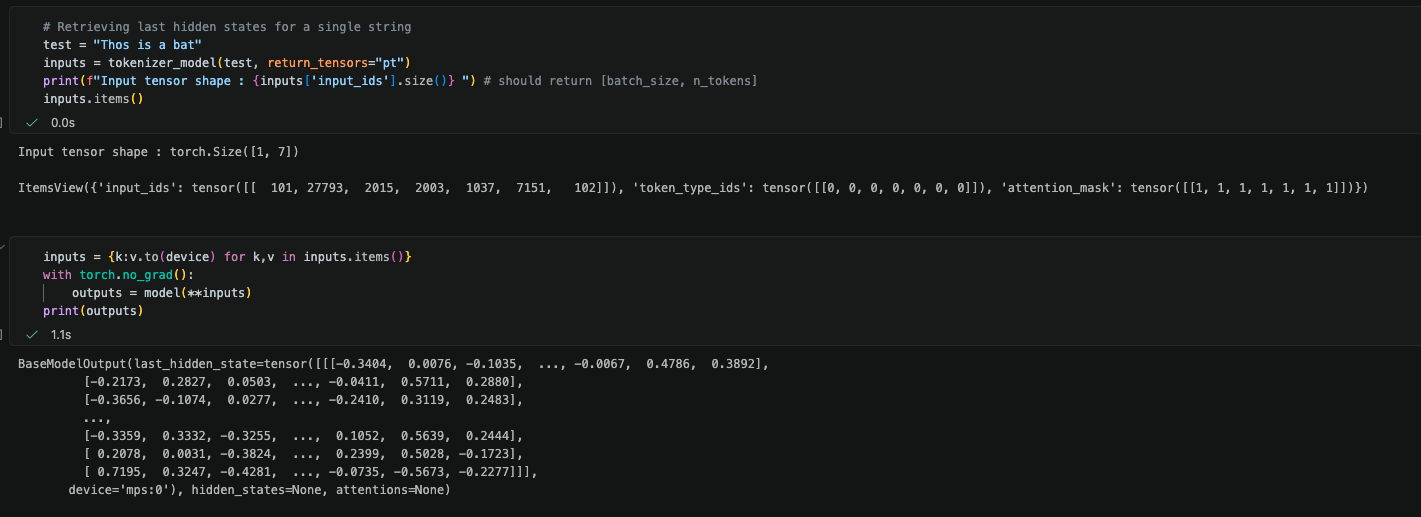

![alt text](image.png)

```python
# **variable unpacks dict into separate keyword arguments:
outputs = model(**inputs)

# Is equivalent to:
outputs = model(
    input_ids=tensor([101, 27793, 2015, ...]),
    token_type_ids=tensor([0, 0, 0, ...]),
    attention_mask=tensor([1, 1, 1, ...])
)

In [54]:
print(outputs.last_hidden_state.size())

torch.Size([1, 7, 768])


* Last hidden state has an embedding dim of 768 for each of the 7 tokens sent to it
* For classification tasks it is common practice to use the hidden state associated with [CLS] as the input feature 
* It appears at the start of every sequence 

In [ ]:
outputs.last_hidden_state[:,0].size() # [:,0] would mean 0th index element from all batches and in this case it ll just be one batch
# remember [CLS] is in itself a token so it ll contain 768 embeddings itself too

torch.Size([1, 768])

In [65]:
def extract_hidden_states(batch):
    inputs = {k:v.to(device) for k, v in batch.items() if k in tokenizer_model.model_input_names}
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state 
    # Return embeddings of the [CLS] token from all sequences in the batch 
    return {last_hidden_state[:,0].cpu().numpy()}

#The map() method requires the processing function to return Python or NumPy objects when we’re using batched inputs.

In [67]:
emotions_encoded.set_format("torch", columns=tokenizer_model.model_input_names)